#  Gender Identification from Voice — AI402 Spring 2026
## Case Study 8: Classifying Speaker Gender Based on Acoustic Features

---
**Team Project | Deadline: May 1, 2026**

This notebook implements a complete speech-based **Gender Identification** pipeline comparing:
- **Primary Model**: CNN (Convolutional Neural Network on Mel-Spectrogram)
- **Baseline Model**: GMM (Gaussian Mixture Model)

**Dataset**: *Gender Recognition by Voice* — 2480 male + 2480 female `.wav` samples

---

##  Section 1: Install & Import Dependencies
All required libraries for audio processing, deep learning (PyTorch + GPU), and classical ML.

In [2]:
import subprocess, sys
pkgs = ['librosa', 'torch', 'torchvision', 'torchaudio',
        'scikit-learn', 'scikit-image', 'matplotlib', 'seaborn',
        'numpy', 'pandas', 'tqdm', 'soundfile', 'joblib']
for p in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])
print('All packages ready ✅')

All packages ready ✅


In [3]:
import os, glob, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import joblib
from tqdm import tqdm
from collections import Counter
from skimage.transform import resize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── GPU setup ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

os.makedirs('plots',  exist_ok=True)
os.makedirs('models', exist_ok=True)

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.2 GB


---
##  Section 2: Dataset Loading & Exploration
##  link : https://www.kaggle.com/datasets/murtadhanajim/gender-recognition-by-voiceoriginal/data
Expected structure:
```
data/
  male/    ← 2480 .wav files
  female/  ← 2480 .wav files
```

In [4]:
# ── UPDATE THIS PATH ──
DATA_ROOT = '/media/mahmoud/LinuxData/Gender_identification/archive/data'

male_files   = sorted(glob.glob(os.path.join(DATA_ROOT, 'male',   '*.wav')))
female_files = sorted(glob.glob(os.path.join(DATA_ROOT, 'female', '*.wav')))

print(f'Male   samples : {len(male_files)}')
print(f'Female samples : {len(female_files)}')
print(f'Total  samples : {len(male_files) + len(female_files)}')

all_files  = male_files  + female_files
all_labels = ['male'] * len(male_files) + ['female'] * len(female_files)

df = pd.DataFrame({'path': all_files, 'label': all_labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print('\nClass distribution:')
print(df['label'].value_counts())

Male   samples : 2480
Female samples : 2480
Total  samples : 4960

Class distribution:
label
female    2480
male      2480
Name: count, dtype: int64


### 2.1 Dataset Balance Visualization

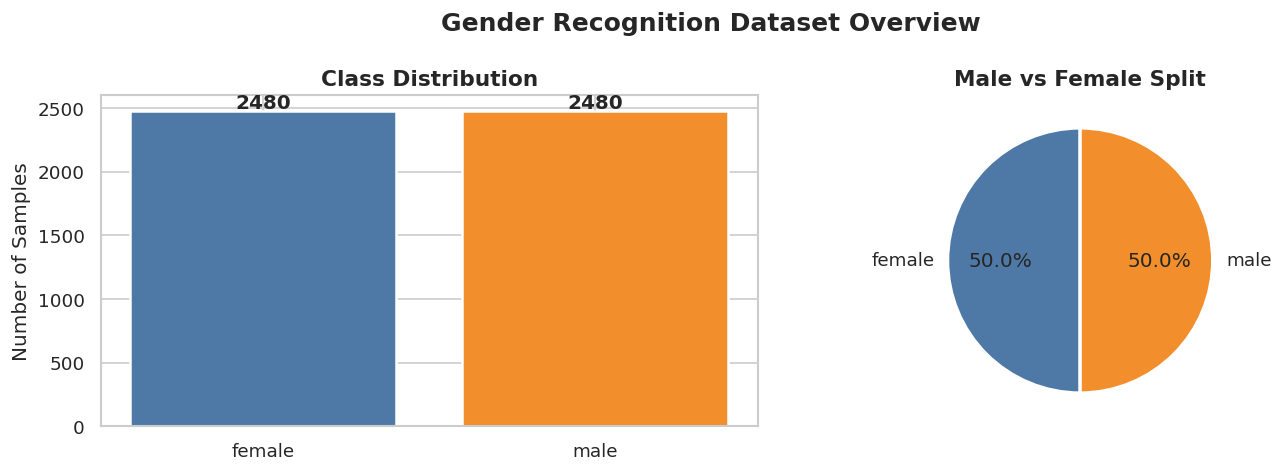

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['label'].value_counts()
colors = ['#4E79A7', '#F28E2B']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Male vs Female Split', fontsize=13, fontweight='bold')

plt.suptitle('Gender Recognition Dataset Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/dataset_distribution.png', bbox_inches='tight')
plt.show()

---
## 🔊 Section 3: Feature Engineering & Selection

### 3.1 Feature Selection Rationale

We evaluated **all 9 candidate features** for Gender Identification:

| # | Feature | Used? | Reason |
|---|---|---|---|
| 1 | **MFCC** | ✅ Yes | Captures vocal tract resonance shape — directly encodes formant frequency differences between male/female voice boxes |
| 2 | **Mel-Spectrogram** | ✅ Yes | 2-D time-frequency representation used as CNN input image; encodes full spectral energy distribution over time |
| 3 | **Frequency (Spectral Centroid + Bandwidth)** | ✅ Yes | Spectral centroid (center of mass of spectrum) captures brightness; male voices have lower centroid. Spectral bandwidth encodes spread around centroid |
| 4 | **Pitch (F0)** | ✅ Yes | Fundamental frequency is the primary gender cue; female ~165–255 Hz, male ~85–155 Hz |
| 5 | **ZCR** | ❌ No | Already partially captured by spectral features + MFCC; adding it causes feature redundancy without improving classification |
| 6 | **RMS Energy** | ❌ No | Highly dependent on recording loudness and microphone gain; does not generalize across different recording conditions |
| 7 | **Timbre** | ❌ No | Timbre differences between genders are already fully captured by MFCC (timbre = tonal quality = vocal tract shape) |
| 8 | **Amplitude** | ❌ No | Raw amplitude is recording-condition-dependent; not a stable gender cue across different environments |
| 9 | **Loudness (LUFS)** | ❌ No | Loudness depends on microphone and environment, not on phonation characteristics specific to gender |

### ✅ Selected Features Summary
1. **MFCC** (40 coefficients + Δ + Δ²) — Main vocal-tract descriptor
2. **Mel-Spectrogram** (128×128 image) — CNN 2-D input / full spectral representation
3. **Spectral Centroid + Bandwidth** — Frequency center-of-mass and spread
4. **Pitch (F0)** — Primary gender discriminator

### ❌ Excluded Features Summary
1. **ZCR** — Redundant with spectral features and MFCC
2. **RMS Energy** — Recording-dependent, not robust
3. **Timbre** — Redundant: already captured by MFCC
4. **Amplitude / Loudness** — Environment-dependent, not gender-specific

### 3.2 Global Feature Configuration

In [6]:
SR       = 22050
DURATION = 5.0
N_MFCC   = 40
N_MELS   = 128
IMG_SIZE = (128, 128)
FMAX     = 8000

feat_config = {
    'sr': SR, 'duration': DURATION, 'n_mfcc': N_MFCC,
    'n_mels': N_MELS, 'img_size': list(IMG_SIZE),
    'fmax': FMAX, 'classes': ['female', 'male']
}

def load_audio(path):
    """Load and pad/trim audio to fixed duration."""
    y, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
    target = int(SR * DURATION)
    y = np.pad(y, (0, max(0, target - len(y))))[:target]
    return y

print('Config set ✅')
print(f'  SR={SR} | Duration={DURATION}s | N_MFCC={N_MFCC} | N_MELS={N_MELS} | IMG={IMG_SIZE}')

Config set ✅
  SR=22050 | Duration=5.0s | N_MFCC=40 | N_MELS=128 | IMG=(128, 128)


### 3.3 Visual Feature Pipeline — Step-by-Step Transformation

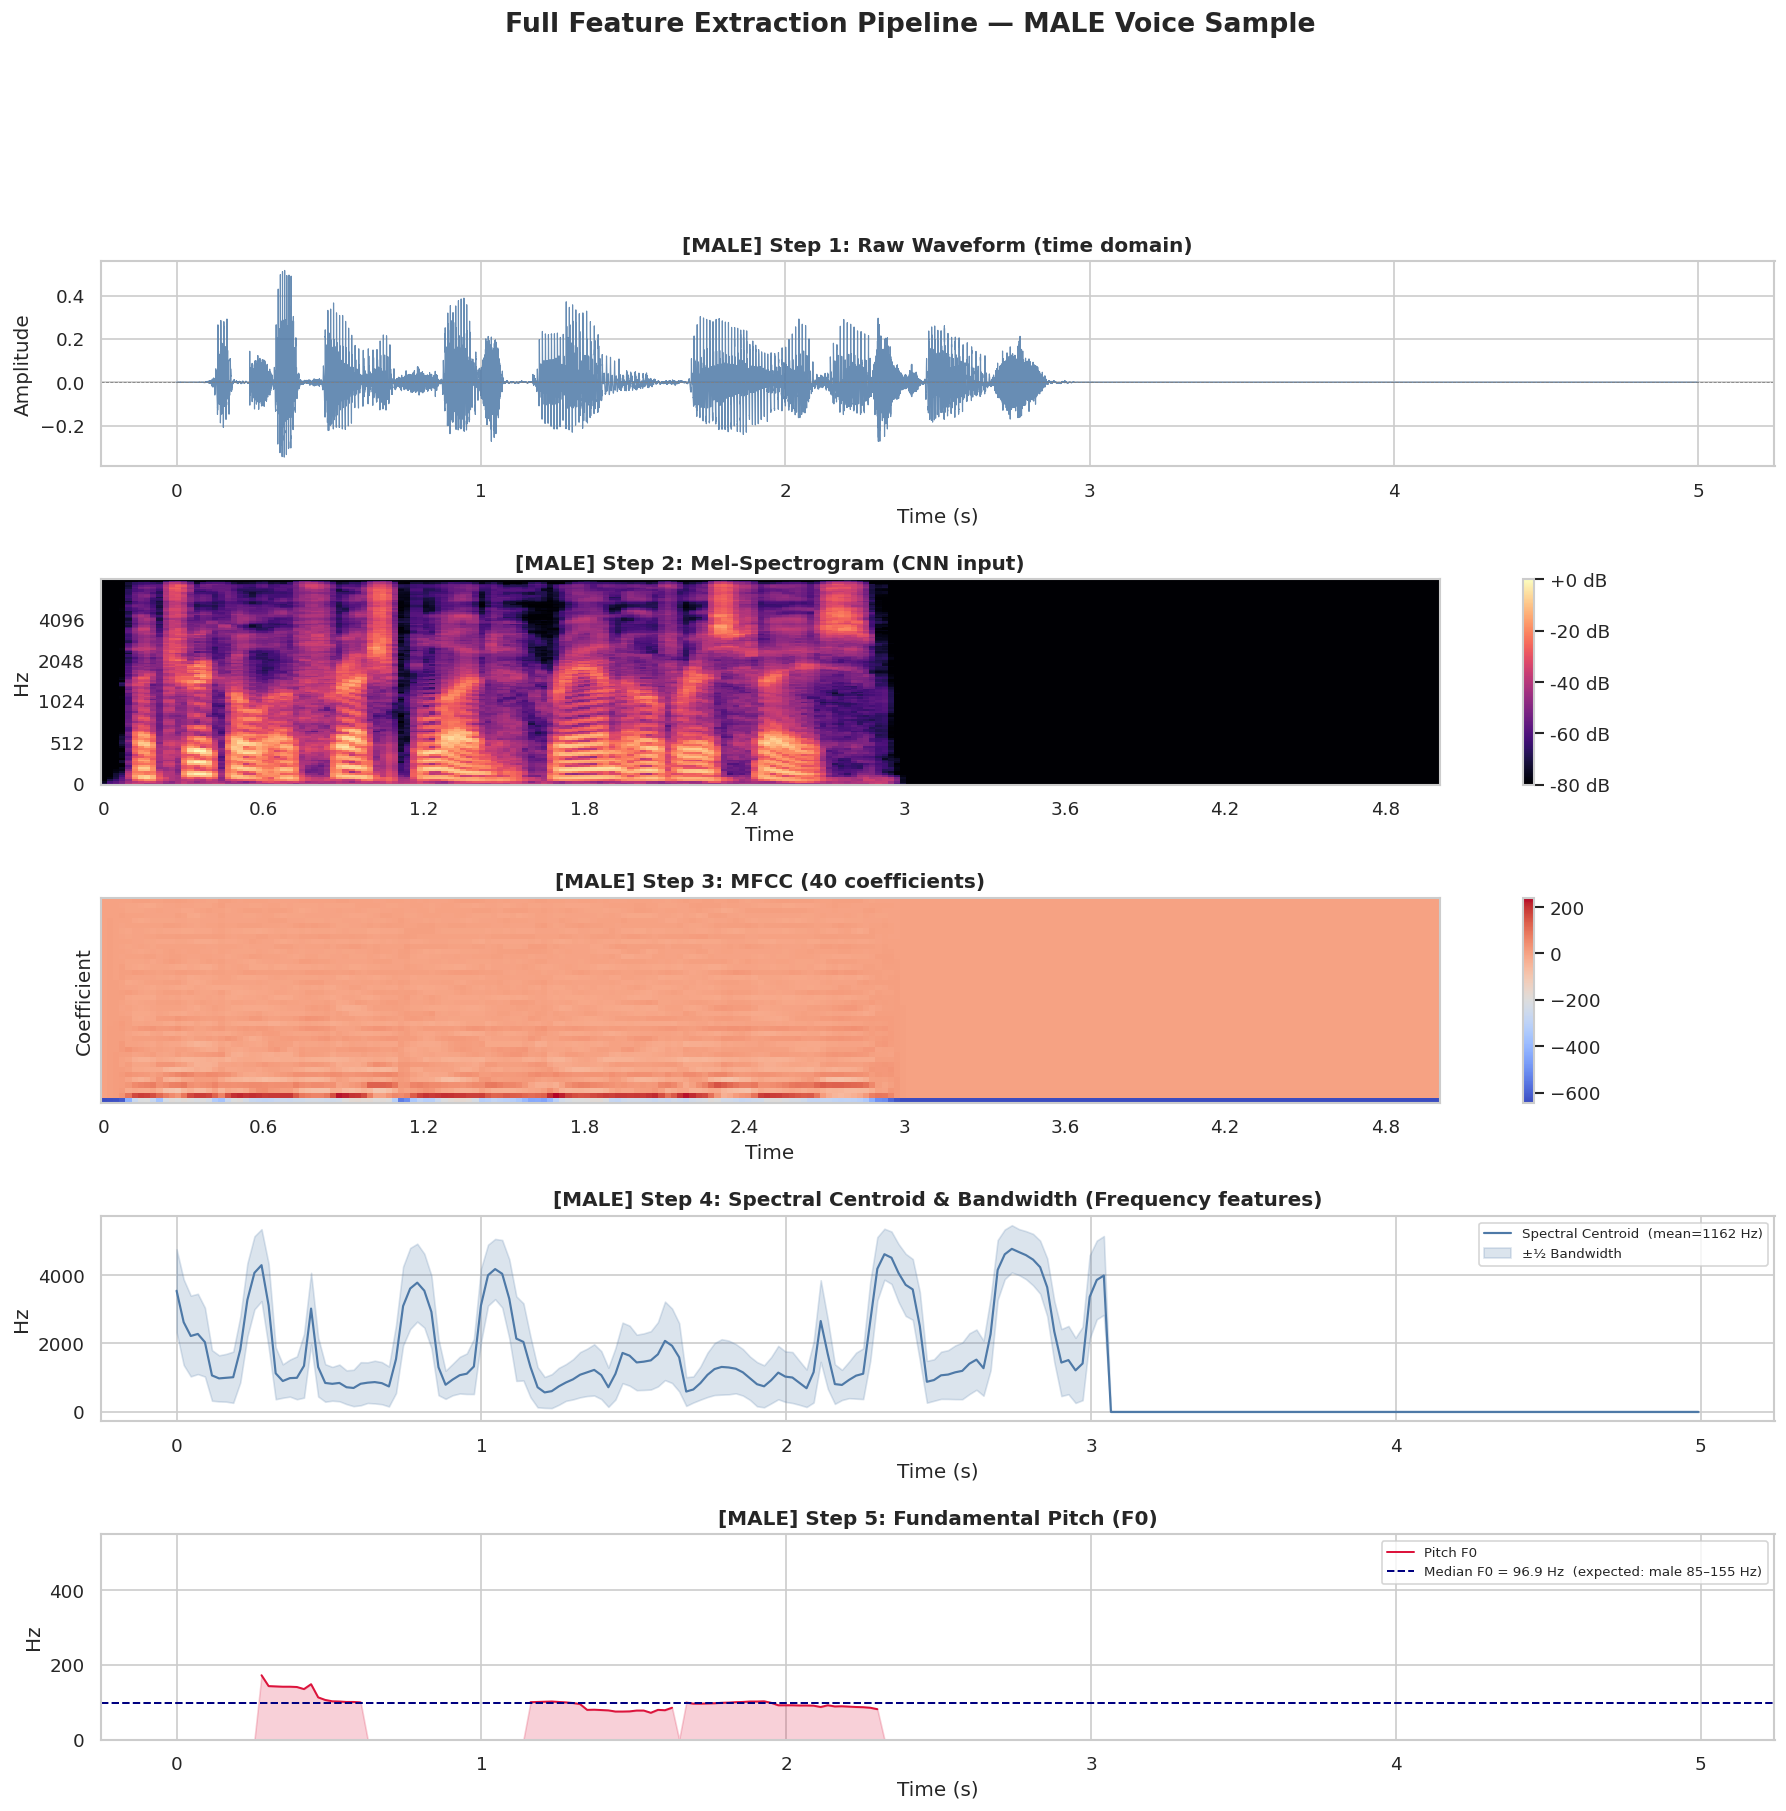

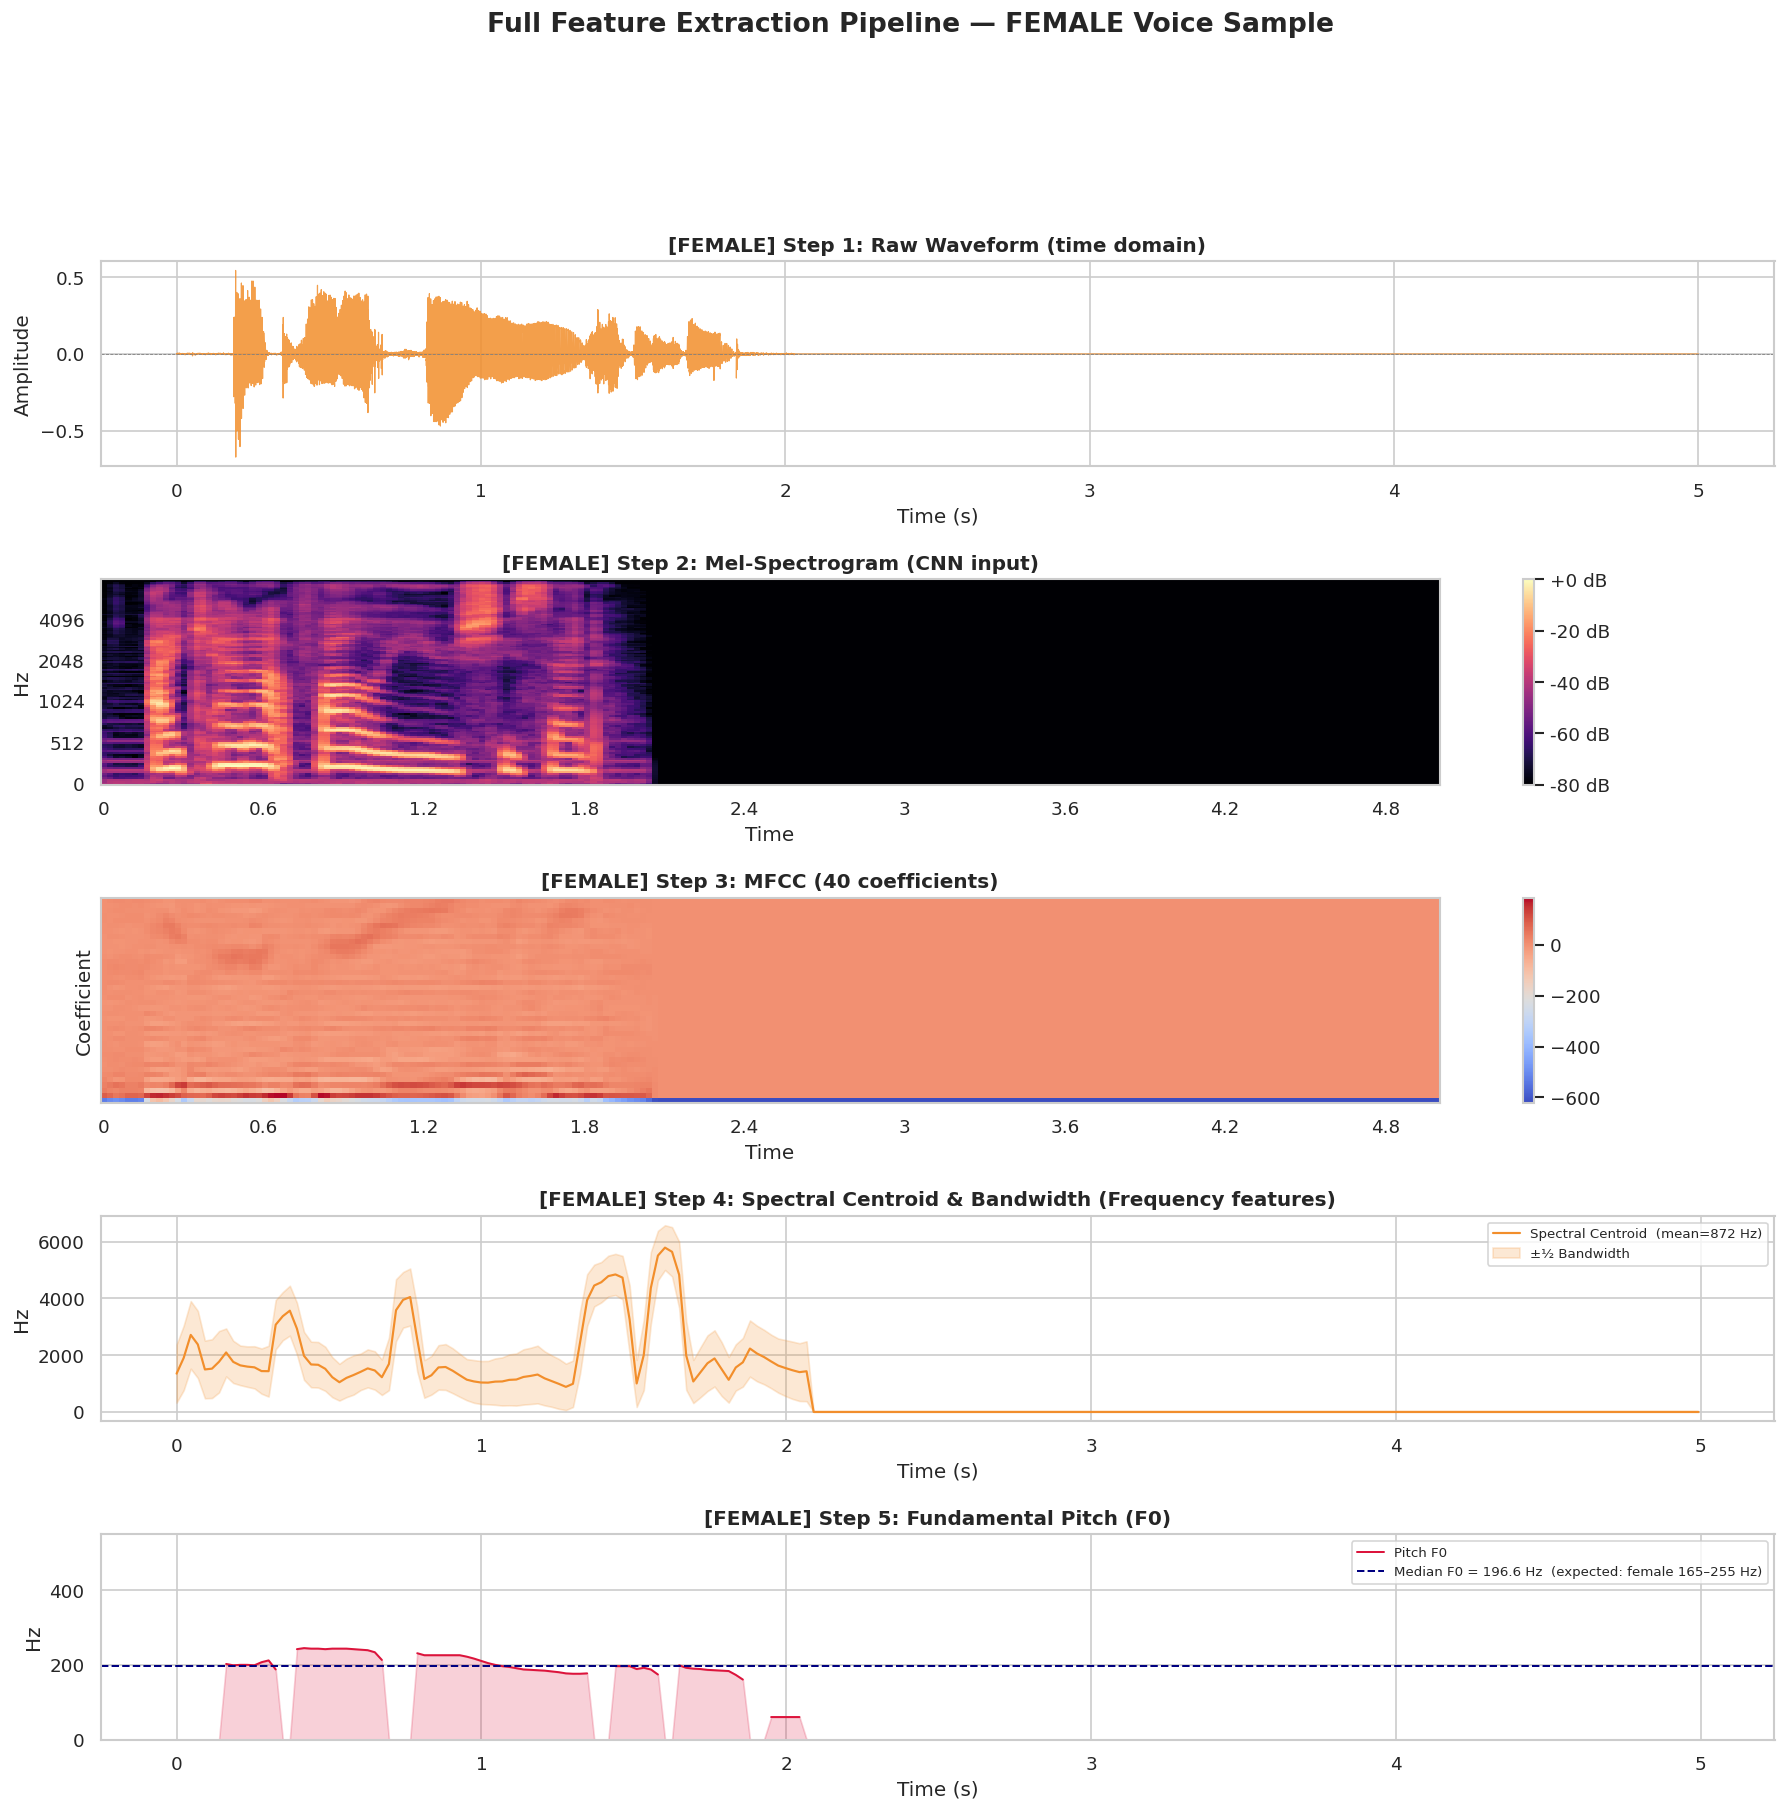

In [7]:
sample_male   = load_audio(random.choice(male_files))
sample_female = load_audio(random.choice(female_files))

def plot_feature_pipeline(y, label, color):
    """Full pipeline: waveform → mel-spec → MFCC → frequency features → pitch."""
    fig = plt.figure(figsize=(18, 16))
    gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

    # ── Step 1: Raw Waveform ──
    ax1 = fig.add_subplot(gs[0, :])
    times = np.linspace(0, DURATION, len(y))
    ax1.plot(times, y, color=color, linewidth=0.7, alpha=0.85)
    ax1.set_title(f'[{label.upper()}] Step 1: Raw Waveform (time domain)', fontweight='bold')
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Amplitude')
    ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    # ── Step 2: Mel-Spectrogram ──
    ax2 = fig.add_subplot(gs[1, :])
    mel    = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, fmax=FMAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SR, x_axis='time',
                                   y_axis='mel', ax=ax2, fmax=FMAX, cmap='magma')
    fig.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title(f'[{label.upper()}] Step 2: Mel-Spectrogram (CNN input)', fontweight='bold')

    # ── Step 3: MFCC ──
    ax3 = fig.add_subplot(gs[2, :])
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    img2 = librosa.display.specshow(mfcc, sr=SR, x_axis='time', ax=ax3, cmap='coolwarm')
    fig.colorbar(img2, ax=ax3)
    ax3.set_title(f'[{label.upper()}] Step 3: MFCC ({N_MFCC} coefficients)', fontweight='bold')
    ax3.set_ylabel('Coefficient')

    # ── Step 4: Spectral Centroid + Bandwidth (Frequency Features) ──
    ax4 = fig.add_subplot(gs[3, :])
    centroid  = librosa.feature.spectral_centroid(y=y, sr=SR)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=SR)[0]
    t_spec = librosa.frames_to_time(np.arange(len(centroid)), sr=SR)
    ax4.plot(t_spec, centroid,  color=color,   linewidth=1.3, label=f'Spectral Centroid  (mean={np.mean(centroid):.0f} Hz)')
    ax4.fill_between(t_spec, centroid - bandwidth/2, centroid + bandwidth/2, alpha=0.2, color=color, label='±½ Bandwidth')
    ax4.set_title(f'[{label.upper()}] Step 4: Spectral Centroid & Bandwidth (Frequency features)', fontweight='bold')
    ax4.set_xlabel('Time (s)'); ax4.set_ylabel('Hz')
    ax4.legend(fontsize=8)

    # ── Step 5: Pitch (F0) ──
    ax5 = fig.add_subplot(gs[4, :])
    f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500)
    t_f0 = librosa.times_like(f0, sr=SR)
    ax5.plot(t_f0, f0, color='crimson', linewidth=1.2, label='Pitch F0')
    ax5.fill_between(t_f0, 0, np.nan_to_num(f0), alpha=0.2, color='crimson')
    valid_f0 = f0[~np.isnan(f0)]
    med_f0   = np.median(valid_f0) if len(valid_f0) > 0 else 0
    ax5.axhline(med_f0, color='navy', linestyle='--', linewidth=1.2,
                label=f'Median F0 = {med_f0:.1f} Hz  (expected: {"male 85–155 Hz" if label=="male" else "female 165–255 Hz"})')
    ax5.set_title(f'[{label.upper()}] Step 5: Fundamental Pitch (F0)', fontweight='bold')
    ax5.set_xlabel('Time (s)'); ax5.set_ylabel('Hz')
    ax5.set_ylim([0, 550])
    ax5.legend(fontsize=8)

    fig.suptitle(f'Full Feature Extraction Pipeline — {label.upper()} Voice Sample',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(f'plots/pipeline_{label}.png', bbox_inches='tight')
    plt.show()

plot_feature_pipeline(sample_male,   'male',   '#4E79A7')
plot_feature_pipeline(sample_female, 'female', '#F28E2B')

### 3.4 Side-by-Side Feature Comparison: Male vs Female

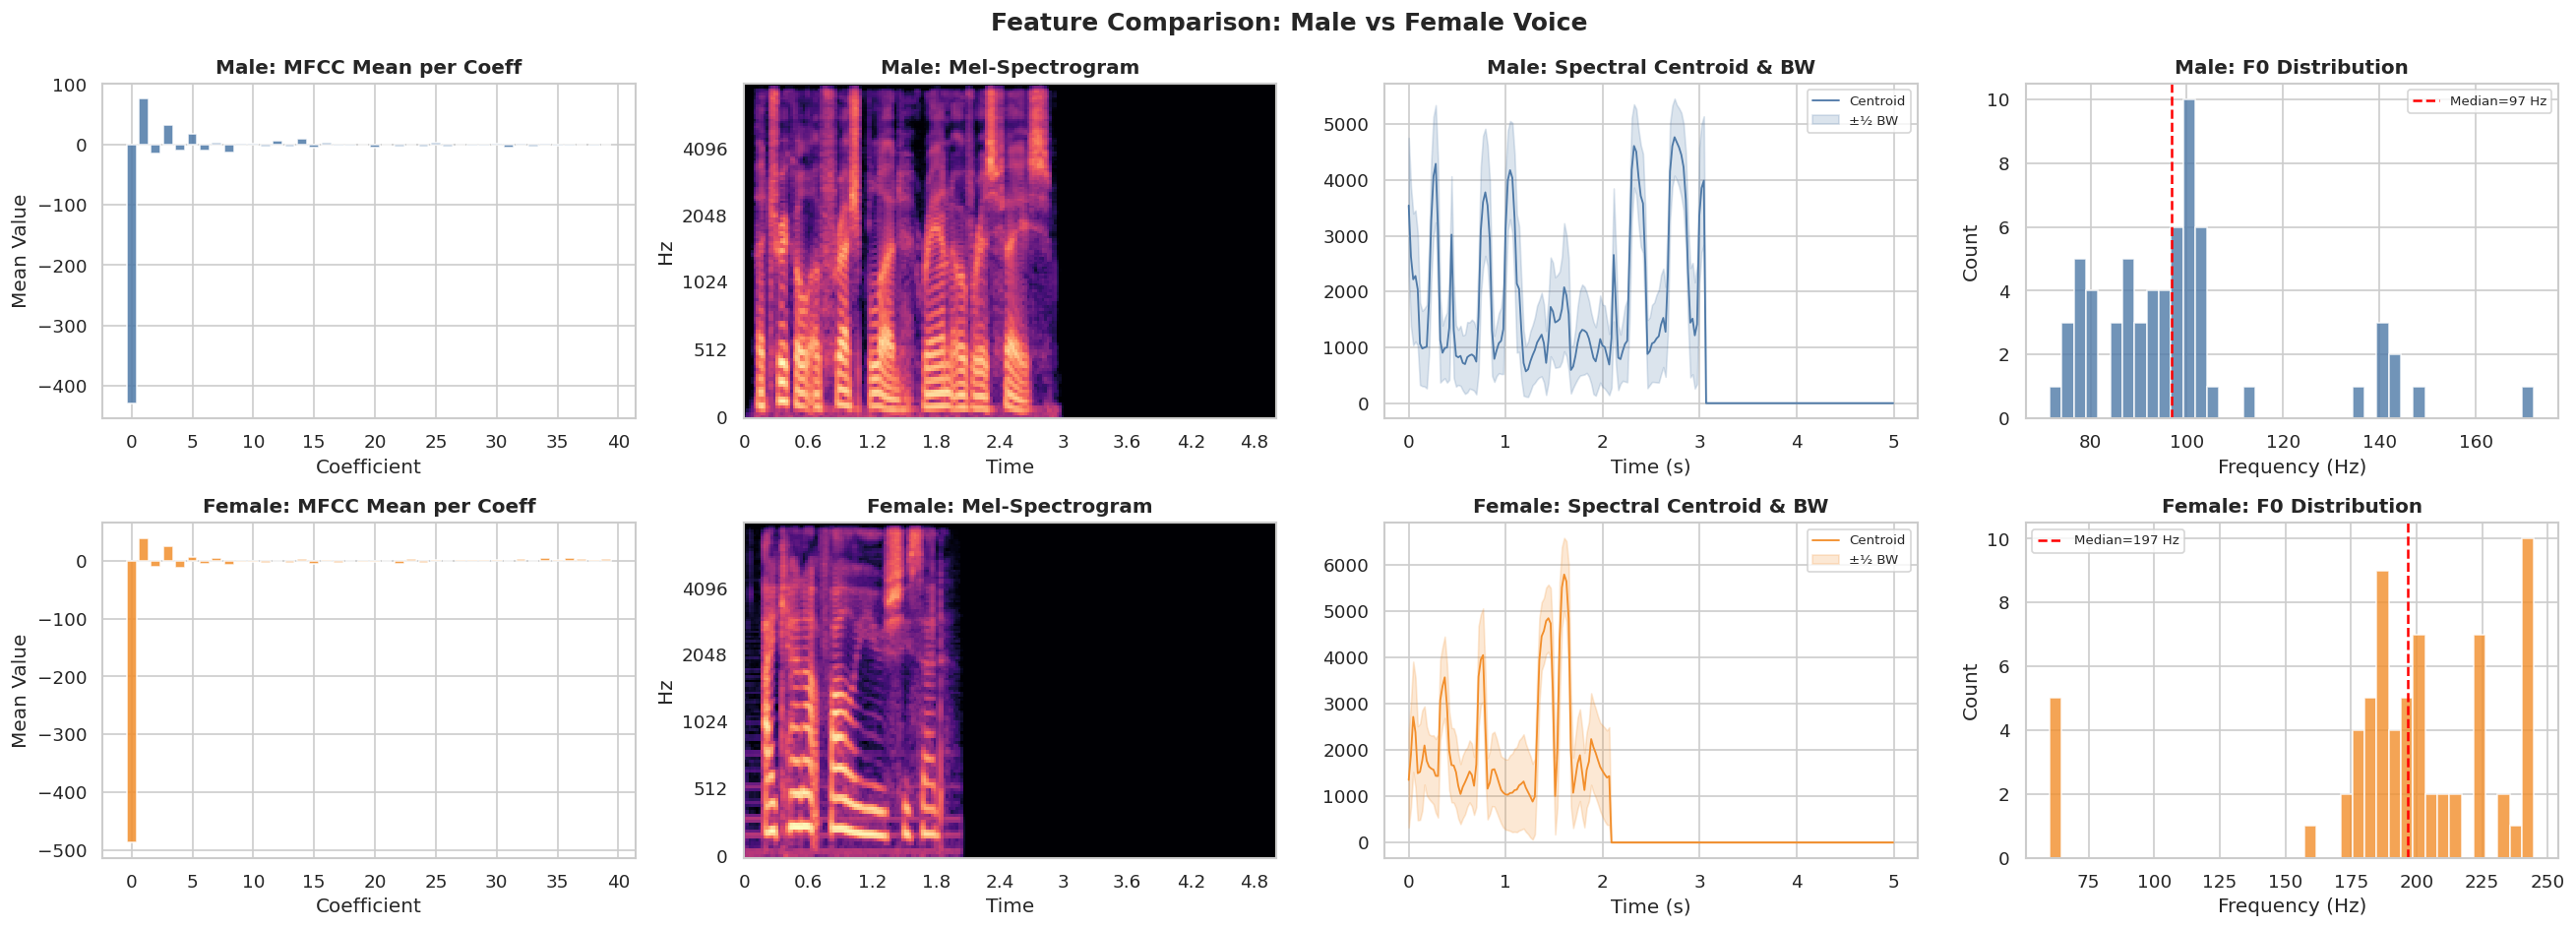

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
samples = [('male', sample_male, '#4E79A7'), ('female', sample_female, '#F28E2B')]

for row, (label, y, color) in enumerate(samples):
    mfcc      = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    centroid  = librosa.feature.spectral_centroid(y=y, sr=SR)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=SR)[0]
    f0, _, _  = librosa.pyin(y, fmin=50, fmax=500)
    mel       = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, fmax=FMAX)
    mel_db    = librosa.power_to_db(mel, ref=np.max)

    # MFCC mean
    axes[row,0].bar(range(N_MFCC), np.mean(mfcc, axis=1), color=color, alpha=0.85)
    axes[row,0].set_title(f'{label.capitalize()}: MFCC Mean per Coeff', fontweight='bold')
    axes[row,0].set_xlabel('Coefficient'); axes[row,0].set_ylabel('Mean Value')

    # Mel-spectrogram thumbnail
    ax_mel = axes[row,1]
    librosa.display.specshow(mel_db, sr=SR, x_axis='time', y_axis='mel',
                             ax=ax_mel, fmax=FMAX, cmap='magma')
    ax_mel.set_title(f'{label.capitalize()}: Mel-Spectrogram', fontweight='bold')

    # Spectral centroid + bandwidth
    t = librosa.frames_to_time(np.arange(len(centroid)), sr=SR)
    axes[row,2].plot(t, centroid, color=color, linewidth=1.1, label='Centroid')
    axes[row,2].fill_between(t, centroid-bandwidth/2, centroid+bandwidth/2,
                              alpha=0.2, color=color, label='±½ BW')
    axes[row,2].set_title(f'{label.capitalize()}: Spectral Centroid & BW', fontweight='bold')
    axes[row,2].set_xlabel('Time (s)'); axes[row,2].legend(fontsize=8)

    # Pitch histogram
    valid_f0 = f0[~np.isnan(f0)]
    axes[row,3].hist(valid_f0, bins=40, color=color, alpha=0.8, edgecolor='white')
    axes[row,3].set_title(f'{label.capitalize()}: F0 Distribution', fontweight='bold')
    axes[row,3].set_xlabel('Frequency (Hz)'); axes[row,3].set_ylabel('Count')
    axes[row,3].axvline(np.median(valid_f0) if len(valid_f0)>0 else 0,
                         color='red', linestyle='--', linewidth=1.5,
                         label=f'Median={np.median(valid_f0) if len(valid_f0)>0 else 0:.0f} Hz')
    axes[row,3].legend(fontsize=8)

plt.suptitle('Feature Comparison: Male vs Female Voice', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_comparison.png', bbox_inches='tight')
plt.show()

---
##  Section 4: Feature Extraction for All Samples

In [9]:
def extract_flat_features(path):
    """
    Flat feature vector for GMM:
      MFCC  (mean+std of 40 coeff)            = 80
      Delta MFCC (mean+std)                   = 80
      Delta2 MFCC (mean+std)                  = 80
      Spectral Centroid (mean, std)            =  2
      Spectral Bandwidth (mean, std)           =  2
      Spectral Rolloff (mean, std)             =  2  ← extra frequency feature
      Pitch F0 (mean, std, median)             =  3
      Total                                    = 249
    """
    try:
        y = load_audio(path)
        mfcc   = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
        dmfcc  = librosa.feature.delta(mfcc)
        d2mfcc = librosa.feature.delta(mfcc, order=2)
        mf  = np.concatenate([mfcc.mean(1),  mfcc.std(1)])
        df_ = np.concatenate([dmfcc.mean(1), dmfcc.std(1)])
        d2f = np.concatenate([d2mfcc.mean(1),d2mfcc.std(1)])

        cent = librosa.feature.spectral_centroid(y=y, sr=SR)[0]
        bw   = librosa.feature.spectral_bandwidth(y=y, sr=SR)[0]
        ro   = librosa.feature.spectral_rolloff(y=y, sr=SR)[0]
        freq_feat = np.array([cent.mean(), cent.std(), bw.mean(), bw.std(),
                               ro.mean(),  ro.std()])

        f0, _, _ = librosa.pyin(y, fmin=50, fmax=500)
        vf0 = f0[~np.isnan(f0)]
        pitch_feat = np.array([
            np.mean(vf0)   if len(vf0)>0 else 0,
            np.std(vf0)    if len(vf0)>0 else 0,
            np.median(vf0) if len(vf0)>0 else 0
        ])
        return np.concatenate([mf, df_, d2f, freq_feat, pitch_feat])
    except:
        return None


def extract_mel_spec(path):
    """Returns (128,128) mel-spectrogram image [0-1] for CNN."""
    try:
        y   = load_audio(path)
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, fmax=FMAX)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return resize(mel_db.astype(np.float32), IMG_SIZE, anti_aliasing=True)
    except:
        return None

print('Feature extraction functions ready ✅')
print(f'Flat feature vector dimension: ~249')

Feature extraction functions ready ✅
Flat feature vector dimension: ~249


In [10]:
# ── Extract flat features (for GMM) ──
print('Extracting flat features for GMM...')
X_flat, y_flat = [], []
for _, row in tqdm(df.iterrows(), total=len(df)):
    feat = extract_flat_features(row['path'])
    if feat is not None:
        X_flat.append(feat)
        y_flat.append(row['label'])

X_flat = np.array(X_flat)
y_flat = np.array(y_flat)
print(f'Shape: {X_flat.shape} | Labels: {Counter(y_flat)}')

Extracting flat features for GMM...


100%|██████████| 4960/4960 [22:01<00:00,  3.75it/s]

Shape: (4960, 249) | Labels: Counter({np.str_('female'): 2480, np.str_('male'): 2480})


In [11]:
# ── Extract mel spectrograms (for CNN) ──
print('Extracting mel spectrograms for CNN...')
X_mel, y_mel = [], []
for _, row in tqdm(df.iterrows(), total=len(df)):
    spec = extract_mel_spec(row['path'])
    if spec is not None:
        X_mel.append(spec)
        y_mel.append(row['label'])

X_mel = np.array(X_mel)
y_mel = np.array(y_mel)
print(f'CNN input shape: {X_mel.shape} | Labels: {Counter(y_mel)}')

Extracting mel spectrograms for CNN...


100%|██████████| 4960/4960 [00:33<00:00, 148.87it/s]

CNN input shape: (4960, 128, 128) | Labels: Counter({np.str_('female'): 2480, np.str_('male'): 2480})


### 4.1 Feature Distribution Analysis (Male vs Female)

Classes: {np.str_('female'): np.int64(0), np.str_('male'): np.int64(1)}


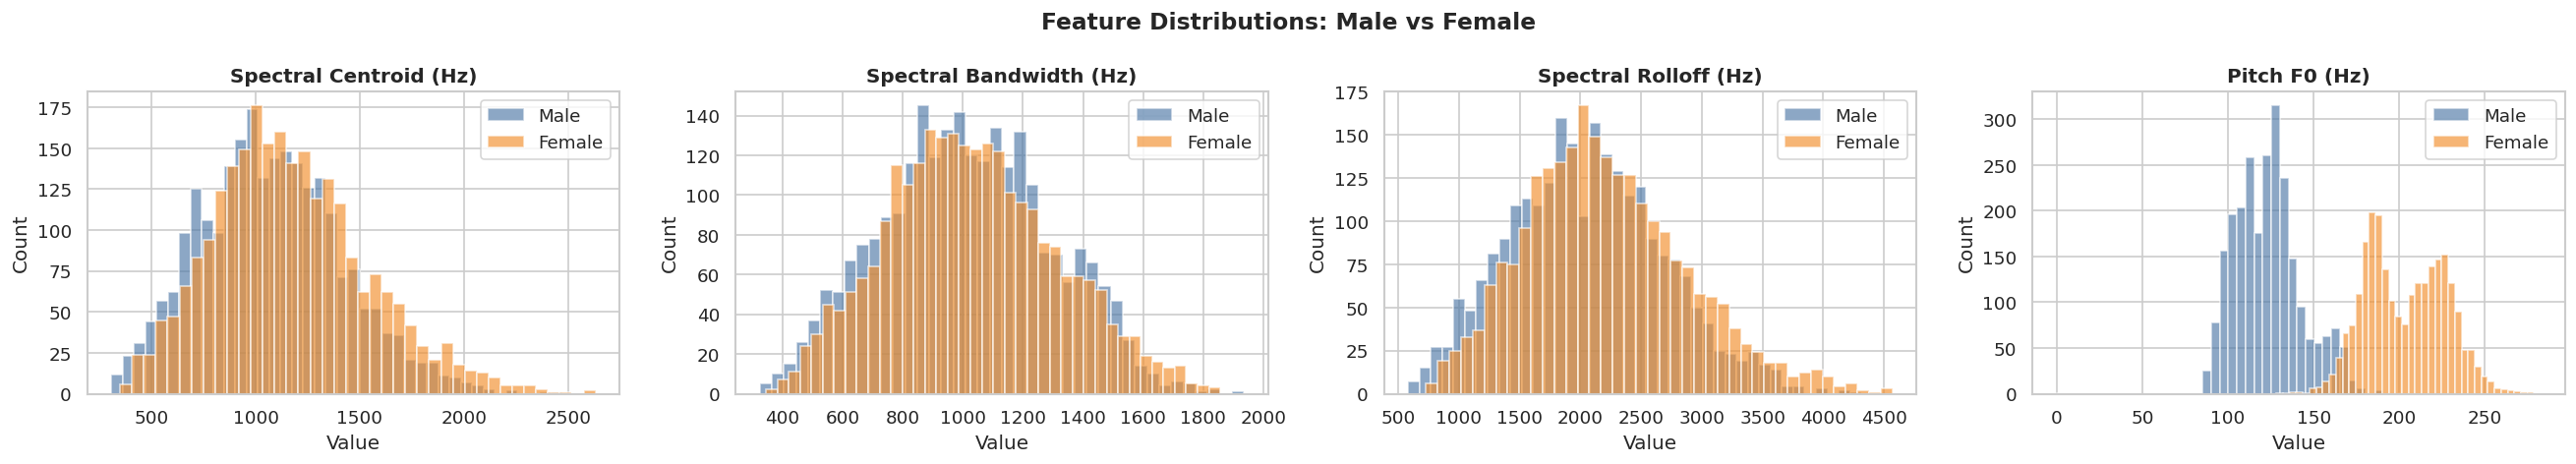

In [12]:
le = LabelEncoder()
y_enc_flat = le.fit_transform(y_flat)
y_enc_mel  = le.transform(y_mel)
print(f'Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

male_idx   = np.where(y_flat == 'male')[0]
female_idx = np.where(y_flat == 'female')[0]

# Feature indices in flat vector: after 240 MFCC features
# centroid_mean=240, centroid_std=241, bw_mean=242, bw_std=243, ro_mean=244, pitch_mean=246
IDX = {'Spectral Centroid (Hz)': 240, 'Spectral Bandwidth (Hz)': 242,
       'Spectral Rolloff (Hz)': 244, 'Pitch F0 (Hz)': 246}

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, (name, idx) in zip(axes, IDX.items()):
    ax.hist(X_flat[male_idx, idx],   bins=40, alpha=0.65, label='Male',   color='#4E79A7')
    ax.hist(X_flat[female_idx, idx], bins=40, alpha=0.65, label='Female', color='#F28E2B')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Feature Distributions: Male vs Female', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', bbox_inches='tight')
plt.show()

---
##  Section 5: Data Splitting & Preprocessing

In [13]:
# ── Split flat features (for GMM) ──
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_flat, y_enc_flat, test_size=0.30, random_state=42, stratify=y_enc_flat)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te  = scaler.transform(X_te)

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le,     'models/label_encoder.pkl')
print(f'Flat split → Train:{len(X_tr)}, Val:{len(X_val)}, Test:{len(X_te)}')

# ── Split mel spectrograms (for CNN) ──
X_mel_tr, X_mel_tmp, y_mel_tr, y_mel_tmp = train_test_split(
    X_mel, y_enc_mel, test_size=0.30, random_state=42, stratify=y_enc_mel)
X_mel_val, X_mel_te, y_mel_val, y_mel_te = train_test_split(
    X_mel_tmp, y_mel_tmp, test_size=0.50, random_state=42, stratify=y_mel_tmp)
print(f'CNN  split → Train:{len(X_mel_tr)}, Val:{len(X_mel_val)}, Test:{len(X_mel_te)}')

Flat split → Train:3472, Val:744, Test:744
CNN  split → Train:3472, Val:744, Test:744


---
##  Section 6: Baseline Model — Gaussian Mixture Model (GMM)

One GMM is trained per class. Classification is done by comparing log-likelihoods:
- If `log P(x | GMM_male) > log P(x | GMM_female)` → predict **Male**
- Otherwise → predict **Female**

In [14]:
# ── GMM Component Search ──
print('Searching best GMM n_components on validation set...')
components_range = [4, 8, 16, 32, 64]
gmm_val_accs = []

X_male_tr   = X_tr[y_tr == le.transform(['male'])[0]]
X_female_tr = X_tr[y_tr == le.transform(['female'])[0]]

def gmm_predict(X, gm, gf, le):
    ll_m = gm.score_samples(X)
    ll_f = gf.score_samples(X)
    preds = np.where(ll_m > ll_f, 'male', 'female')
    return le.transform(preds)

for n in components_range:
    gm = GaussianMixture(n_components=n, covariance_type='diag', max_iter=200, random_state=42)
    gf = GaussianMixture(n_components=n, covariance_type='diag', max_iter=200, random_state=42)
    gm.fit(X_male_tr); gf.fit(X_female_tr)
    acc = accuracy_score(y_val, gmm_predict(X_val, gm, gf, le))
    gmm_val_accs.append(acc)
    print(f'  n_components={n:3d}  →  Val Acc = {acc*100:.2f}%')

best_n = components_range[np.argmax(gmm_val_accs)]
print(f'\nBest n_components = {best_n}  (Val Acc = {max(gmm_val_accs)*100:.2f}%)')

Searching best GMM n_components on validation set...
  n_components=  4  →  Val Acc = 97.98%
  n_components=  8  →  Val Acc = 98.92%
  n_components= 16  →  Val Acc = 99.46%
  n_components= 32  →  Val Acc = 99.87%
  n_components= 64  →  Val Acc = 99.87%

Best n_components = 32  (Val Acc = 99.87%)


Best GMM saved ✅


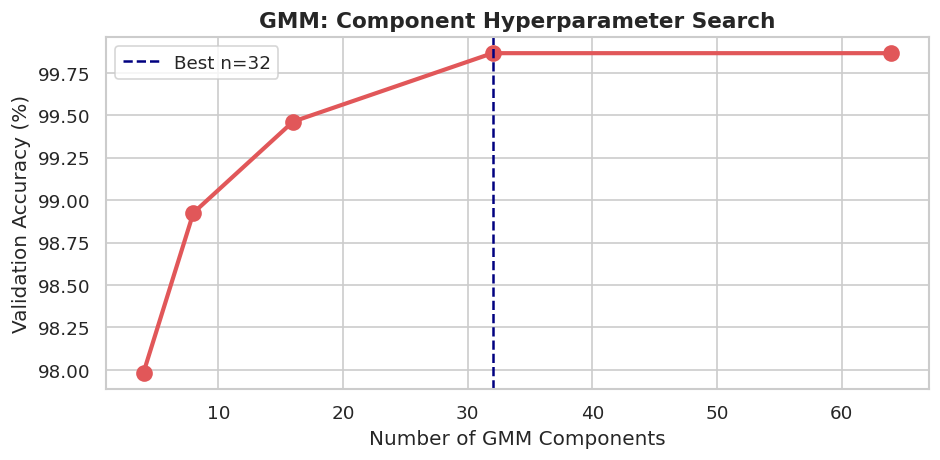

In [15]:
# ── Train best GMM ──
gmm_male   = GaussianMixture(n_components=best_n, covariance_type='diag', max_iter=200, random_state=42)
gmm_female = GaussianMixture(n_components=best_n, covariance_type='diag', max_iter=200, random_state=42)
gmm_male.fit(X_male_tr)
gmm_female.fit(X_female_tr)
joblib.dump(gmm_male,   'models/gmm_male.pkl')
joblib.dump(gmm_female, 'models/gmm_female.pkl')
print('Best GMM saved ✅')

# Component search plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(components_range, [a*100 for a in gmm_val_accs],
        marker='o', color='#E15759', linewidth=2.5, markersize=9)
ax.axvline(best_n, color='navy', linestyle='--', linewidth=1.5, label=f'Best n={best_n}')
ax.set_xlabel('Number of GMM Components', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('GMM: Component Hyperparameter Search', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('plots/gmm_component_search.png', bbox_inches='tight')
plt.show()

---
##  Section 7: Primary Model — CNN (Convolutional Neural Network)

**Architecture**: 3 convolutional blocks on 128×128 mel-spectrograms.
- Input: `(batch, 1, 128, 128)` — single-channel mel-spectrogram
- Each block: `Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool → Dropout`
- Head: `AdaptiveAvgPool → Flatten → FC(256) → FC(64) → FC(2)`
- Trained on **GPU** with AdamW + Cosine Annealing LR

In [16]:
class MelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 64
cnn_train_dl = DataLoader(MelDataset(X_mel_tr,  y_mel_tr),  batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
cnn_val_dl   = DataLoader(MelDataset(X_mel_val, y_mel_val), batch_size=BATCH, shuffle=False, num_workers=2)
cnn_test_dl  = DataLoader(MelDataset(X_mel_te,  y_mel_te),  batch_size=BATCH, shuffle=False, num_workers=2)
print('DataLoaders ready ✅')

DataLoaders ready ✅


In [17]:
class GenderCNN(nn.Module):
    """CNN for gender classification from mel-spectrograms."""
    def __init__(self, num_classes=2):
        super().__init__()
        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
            )
        self.features = nn.Sequential(
            conv_block(1,   32),
            conv_block(32,  64),
            conv_block(64, 128),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 64),      nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = GenderCNN().to(DEVICE)
n_params  = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'CNN Parameters: {n_params:,}')
print(cnn_model)

CNN Parameters: 828,450
GenderCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.25, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [18]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        out  = model(X_b)
        loss = criterion(out, y_b)
        probs = torch.softmax(out, dim=1)
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y_b.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
    return total_loss/total, correct/total, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print('Training utilities ready ✅')

Training utilities ready ✅


### 7.1 Train CNN

In [19]:
EPOCHS   = 5
LR       = 1e-3
PATIENCE = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(cnn_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

cnn_history    = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc   = 0.0
patience_count = 0

print('='*55)
print('  TRAINING CNN — GPU:', DEVICE)
print('='*55)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(cnn_model, cnn_train_dl, optimizer, criterion)
    vl_loss, vl_acc, _, _, _ = eval_epoch(cnn_model, cnn_val_dl, criterion)
    scheduler.step()

    cnn_history['train_loss'].append(tr_loss)
    cnn_history['val_loss'].append(vl_loss)
    cnn_history['train_acc'].append(tr_acc)
    cnn_history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(cnn_model.state_dict(), 'models/cnn_best.pth')
        patience_count = 0
        mark = '⭐'
    else:
        patience_count += 1
        mark = ''

    if epoch % 5 == 0 or patience_count == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train: loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | '
              f'Val: loss={vl_loss:.4f} acc={vl_acc*100:.2f}% {mark}')

    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\n✅ Best Val Acc (CNN): {best_val_acc*100:.2f}%')

  TRAINING CNN — GPU: cuda
Epoch   1/5 | Train: loss=0.3492 acc=82.63% | Val: loss=0.5519 acc=62.90% ⭐
Epoch   2/5 | Train: loss=0.0697 acc=97.72% | Val: loss=0.0086 acc=99.87% ⭐
Epoch   5/5 | Train: loss=0.0115 acc=99.57% | Val: loss=0.0056 acc=99.87% 

✅ Best Val Acc (CNN): 99.87%


### 7.2 CNN Training Curves

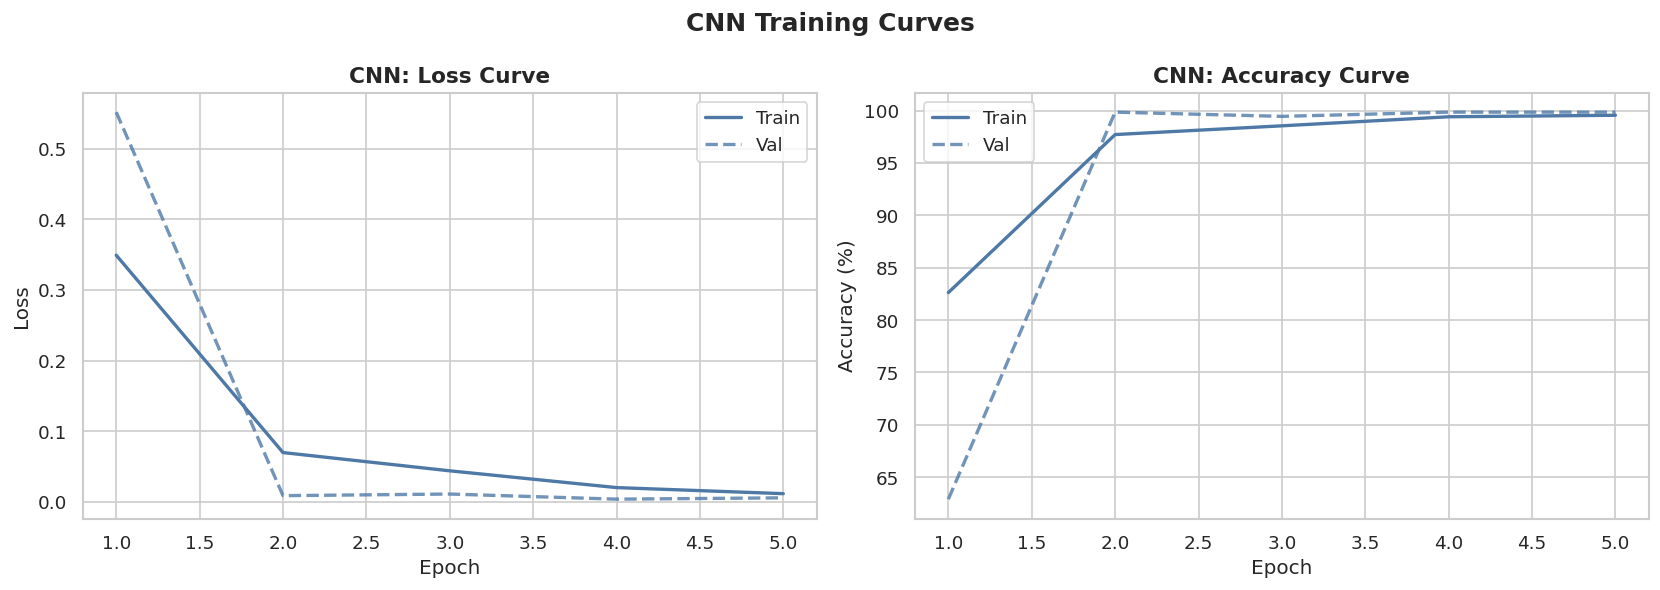

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
e = range(1, len(cnn_history['train_loss']) + 1)

axes[0].plot(e, cnn_history['train_loss'], label='Train', color='#4E79A7', linewidth=2)
axes[0].plot(e, cnn_history['val_loss'],   label='Val',   color='#4E79A7', linewidth=2, linestyle='--', alpha=0.8)
axes[0].set_title('CNN: Loss Curve', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(e, [a*100 for a in cnn_history['train_acc']], label='Train', color='#4E79A7', linewidth=2)
axes[1].plot(e, [a*100 for a in cnn_history['val_acc']],   label='Val',   color='#4E79A7', linewidth=2, linestyle='--', alpha=0.8)
axes[1].set_title('CNN: Accuracy Curve', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.suptitle('CNN Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/cnn_training_curves.png', bbox_inches='tight')
plt.show()

---
##  Section 8: Final Evaluation — CNN vs GMM on Test Set

In [21]:
# ── Load best CNN ──
cnn_model.load_state_dict(torch.load('models/cnn_best.pth', map_location=DEVICE))
_, cnn_test_acc, y_cnn_pred, y_cnn_true, y_cnn_prob = eval_epoch(cnn_model, cnn_test_dl, criterion)

# ── GMM test ──
y_gmm_pred   = gmm_predict(X_te, gmm_male, gmm_female, le)
gmm_test_acc = accuracy_score(y_te, y_gmm_pred)

# GMM log-likelihood ratio as probability score for ROC
ll_m         = gmm_male.score_samples(X_te)
ll_f         = gmm_female.score_samples(X_te)
y_gmm_prob   = 1 / (1 + np.exp(-(ll_m - ll_f) / 10))

class_names = le.classes_.tolist()

print('='*55)
print(f'  CNN  Test Accuracy : {cnn_test_acc*100:.2f}%')
print(f'  GMM  Test Accuracy : {gmm_test_acc*100:.2f}%')
print('='*55)

  CNN  Test Accuracy : 99.60%
  GMM  Test Accuracy : 99.60%


### 8.1 Classification Reports

In [22]:
print('──────────────────────────────────────────')
print('CNN Classification Report:')
print('──────────────────────────────────────────')
print(classification_report(y_cnn_true, y_cnn_pred, target_names=class_names))

print('──────────────────────────────────────────')
print('GMM Classification Report:')
print('──────────────────────────────────────────')
print(classification_report(y_te, y_gmm_pred, target_names=class_names))

──────────────────────────────────────────
CNN Classification Report:
──────────────────────────────────────────
              precision    recall  f1-score   support

      female       0.99      1.00      1.00       372
        male       1.00      0.99      1.00       372

    accuracy                           1.00       744
   macro avg       1.00      1.00      1.00       744
weighted avg       1.00      1.00      1.00       744

──────────────────────────────────────────
GMM Classification Report:
──────────────────────────────────────────
              precision    recall  f1-score   support

      female       0.99      1.00      1.00       372
        male       1.00      0.99      1.00       372

    accuracy                           1.00       744
   macro avg       1.00      1.00      1.00       744
weighted avg       1.00      1.00      1.00       744



### 8.2 Confusion Matrices — CNN vs GMM

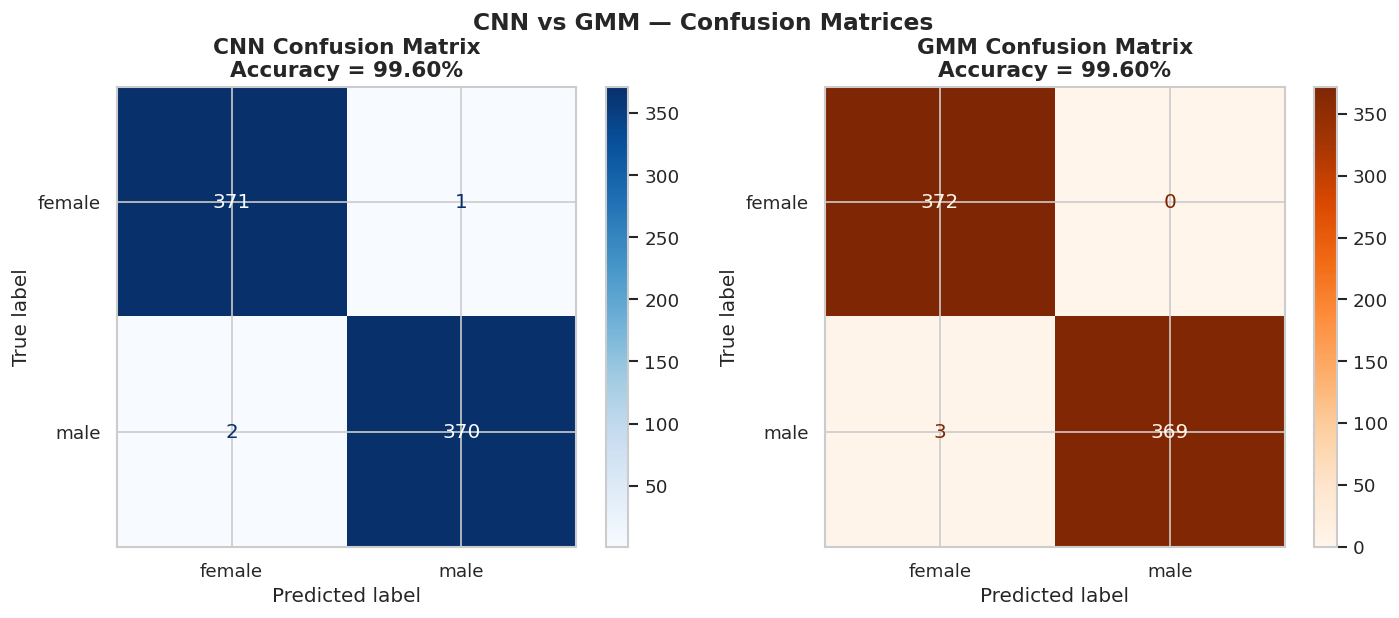

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_true, y_pred, color) in zip(axes, [
        ('CNN', y_cnn_true, y_cnn_pred, 'Blues'),
        ('GMM', y_te,       y_gmm_pred, 'Oranges')]):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap=color)
    ax.set_title(f'{name} Confusion Matrix\nAccuracy = {accuracy_score(y_true,y_pred)*100:.2f}%',
                 fontweight='bold', fontsize=13)

plt.suptitle('CNN vs GMM — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/confusion_matrices_cnn_vs_gmm.png', bbox_inches='tight')
plt.show()

### 8.3 ROC Curves — CNN vs GMM

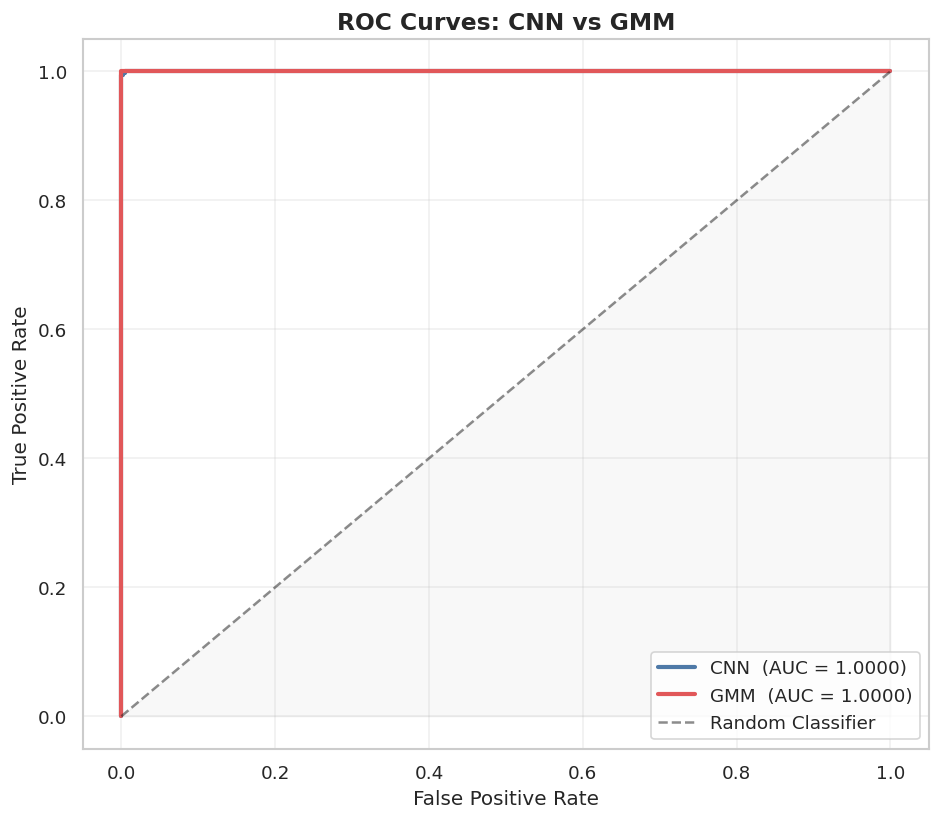

In [24]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, y_true, y_prob, color in [
        ('CNN', y_cnn_true, y_cnn_prob, '#4E79A7'),
        ('GMM', y_te,       y_gmm_prob, '#E15759')]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: CNN vs GMM', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/roc_cnn_vs_gmm.png', bbox_inches='tight')
plt.show()

### 8.4 Performance Comparison Bar Chart — CNN vs GMM


Full Comparison Table:
     Accuracy  Precision  Recall  F1-Score
CNN      99.6       99.6    99.6      99.6
GMM      99.6       99.6    99.6      99.6


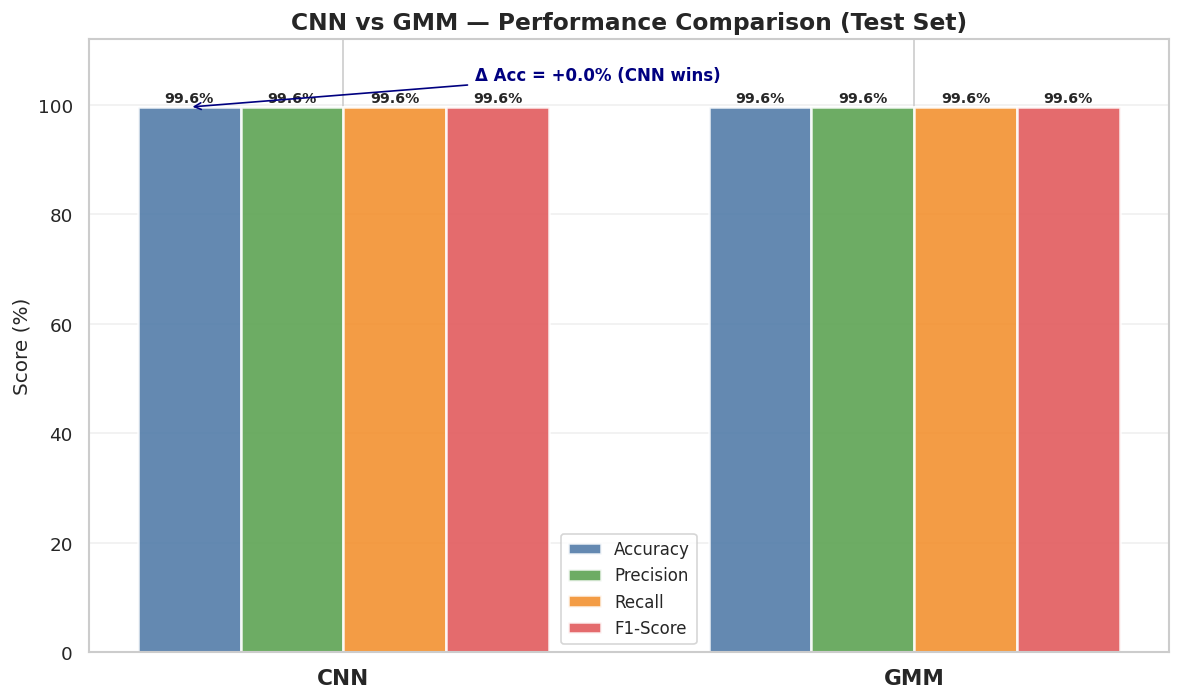

In [25]:
results = {}
for name, y_true, y_pred in [('CNN', y_cnn_true, y_cnn_pred), ('GMM', y_te, y_gmm_pred)]:
    results[name] = {
        'Accuracy':  accuracy_score(y_true, y_pred)                     * 100,
        'Precision': precision_score(y_true, y_pred, average='macro')   * 100,
        'Recall':    recall_score(y_true, y_pred, average='macro')      * 100,
        'F1-Score':  f1_score(y_true, y_pred, average='macro')          * 100,
    }

results_df = pd.DataFrame(results).T
print('\nFull Comparison Table:')
print(results_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x      = np.arange(len(results_df))
width  = 0.18
colors = ['#4E79A7', '#59A14F', '#F28E2B', '#E15759']

for i, (metric, color) in enumerate(zip(results_df.columns, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width,
                  label=metric, color=color, alpha=0.88, edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df.index, fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('CNN vs GMM — Performance Comparison (Test Set)', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim([0, 112])
ax.grid(axis='y', alpha=0.3)

# Highlight CNN advantage
cnn_acc = results['CNN']['Accuracy']
gmm_acc = results['GMM']['Accuracy']
ax.annotate(f'Δ Acc = +{cnn_acc-gmm_acc:.1f}% (CNN wins)',
            xy=(0, cnn_acc), xytext=(0.5, cnn_acc+5),
            fontsize=10, color='navy', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='navy'))

plt.tight_layout()
plt.savefig('plots/cnn_vs_gmm_comparison.png', bbox_inches='tight')
plt.show()

### 8.5 Accuracy Comparison Summary

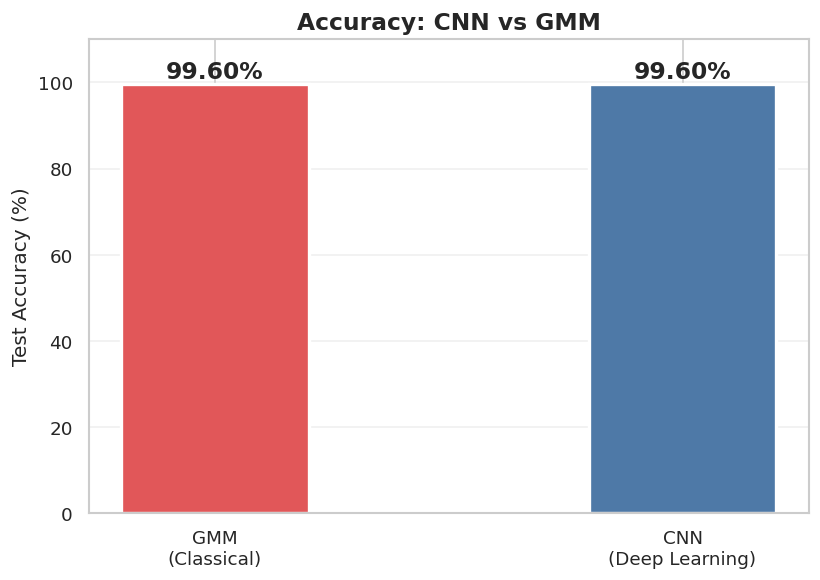

CNN Accuracy  : 99.60%
GMM Accuracy  : 99.60%
CNN Advantage : +0.00%


In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
models  = ['GMM\n(Classical)', 'CNN\n(Deep Learning)']
accs    = [results['GMM']['Accuracy'], results['CNN']['Accuracy']]
colors  = ['#E15759', '#4E79A7']

bars = ax.bar(models, accs, color=colors, edgecolor='white', linewidth=2, width=0.4)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Accuracy: CNN vs GMM', fontweight='bold', fontsize=14)
ax.set_ylim([0, 110])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/accuracy_cnn_vs_gmm.png', bbox_inches='tight')
plt.show()

print(f'CNN Accuracy  : {results["CNN"]["Accuracy"]:.2f}%')
print(f'GMM Accuracy  : {results["GMM"]["Accuracy"]:.2f}%')
print(f'CNN Advantage : +{results["CNN"]["Accuracy"]-results["GMM"]["Accuracy"]:.2f}%')

---
##  Section 10: Save All Models & Configs for Flask

In [27]:
with open('models/feat_config.json', 'w') as f:
    json.dump(feat_config, f)

cnn_cfg = {'type': 'cnn', 'num_classes': 2,
           'flat_dim': X_flat.shape[1]}
with open('models/cnn_config.json', 'w') as f:
    json.dump(cnn_cfg, f)

print('All models saved:')
for fname in sorted(os.listdir('models')):
    p = os.path.join('models', fname)
    print(f'  {fname:30s}  {os.path.getsize(p)/1024:.1f} KB')

All models saved:
  cnn_best.pth                    3255.6 KB
  cnn_config.json                 0.0 KB
  feat_config.json                0.1 KB
  gmm_female.pkl                  250.5 KB
  gmm_male.pkl                    250.5 KB
  label_encoder.pkl               0.4 KB
  scaler.pkl                      6.4 KB
